# Desarrollo

## Importación de librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


## Carga de datos

In [3]:
df = pd.read_csv('diabetes.csv')


## Preprocesamiento de datos

### Separación características y variable objetivo

In [4]:
X_completa = df.drop('Outcome', axis=1)
y = df['Outcome']


### Detección y tratamiento de valores faltantes

In [5]:
# los 0s en estas columnas son datos ausentes, no valores reales
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_completa[cols] = X_completa[cols].replace(0, np.nan)
X_completa.fillna(X_completa.mean(), inplace=True)


### División subconjuntos entrenamiento y prueba

In [6]:
# 80/20 — dataset de ~768 muestras, no nos podemos permitir más test
X_train, X_test, y_train, y_test = train_test_split(X_completa, y, test_size=0.2, random_state=42)

# verificamos distribución de clases para detectar desbalance
print(y_train.value_counts(), "\n")
print(y_test.value_counts())


Outcome
0    401
1    213
Name: count, dtype: int64 

Outcome
0    99
1    55
Name: count, dtype: int64


### Normalización

In [7]:
# fit solo sobre train para no contaminar con info del test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Selección de variables

In [8]:
df_corr = df.copy()
correlation = df_corr.corr(numeric_only=True)['Outcome'].sort_values(ascending=False)
print(correlation)


Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


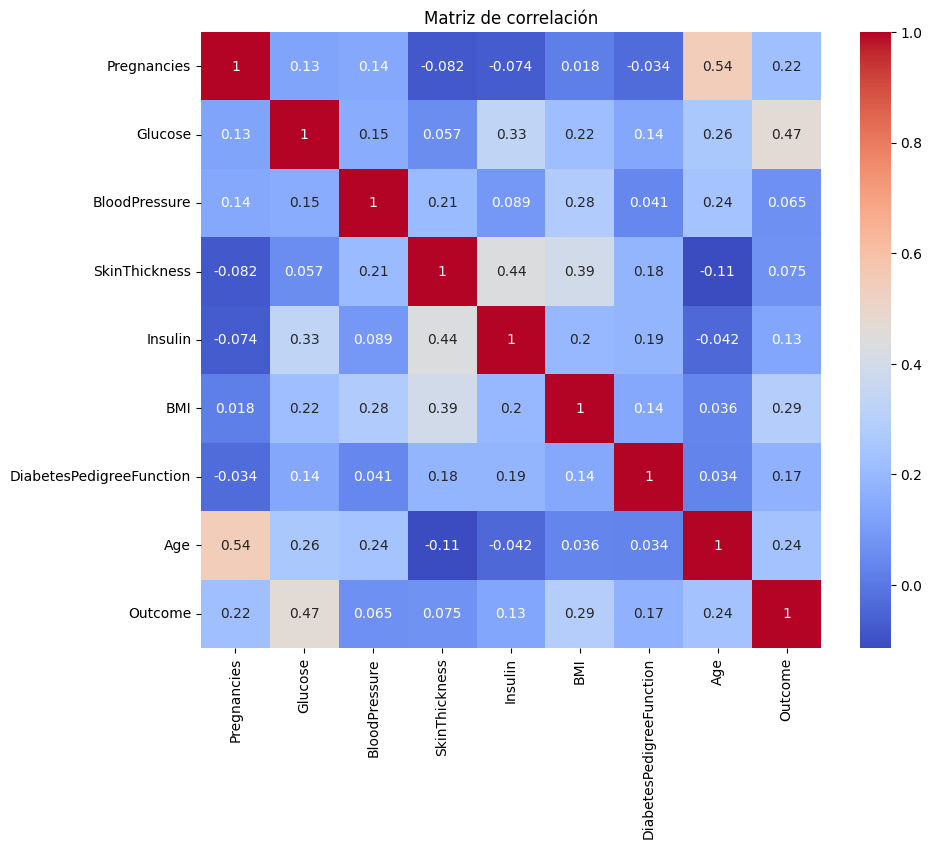

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


In [10]:
# umbral 0.1 — conservador, con 768 muestras no sobran variables
selected_features = correlation[abs(correlation) > 0.1].index.tolist()
selected_features = [f for f in selected_features if f != 'Outcome']
print("Variables seleccionadas:", selected_features)

X = df[selected_features].copy()


Variables seleccionadas: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction', 'Insulin']


In [11]:
# BloodPressure y SkinThickness quedaron fuera, no hace falta tratarlas
new_cols = ['Glucose', 'BMI', 'Insulin']
X[new_cols] = X[new_cols].replace(0, np.nan)
X.fillna(X.mean(), inplace=True)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Implementación de modelos con ajuste de hiperparámetros

### Regresión Logística

In [14]:
log_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',  # mejor que lbfgs para datasets pequeños
    random_state=42
)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# F1 como métrica — más justo que accuracy con clases desbalanceadas
grid_log = GridSearchCV(log_model, param_grid_log, cv=5, scoring='f1', n_jobs=-1)
grid_log.fit(X_train_scaled, y_train)
log_model = grid_log.best_estimator_

y_pred_log = log_model.predict(X_test_scaled)


### Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}


grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
rf_model = grid_rf.best_estimator_

y_pred_rf = rf_model.predict(X_test_scaled)


### Support Vector Machines (SVM)

In [16]:
# probability=True necesario para las curvas ROC
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(svm_model, param_grid_svc, cv=5, scoring='f1', n_jobs=-1)
grid_svc.fit(X_train_scaled, y_train)
svm_model = grid_svc.best_estimator_

y_pred_svm = svm_model.predict(X_test_scaled)


### Redes Neuronales

In [17]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(10, 8),
    activation='relu',
    solver='adam',
    max_iter=2000,  # subimos iteraciones porque a veces no converge con el default
    random_state=42
)

param_grid_mlp = {
    'hidden_layer_sizes': [(10, 8), (50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(mlp_model, param_grid_mlp, cv=5, scoring='f1', n_jobs=-1)
grid_mlp.fit(X_train_scaled, y_train)
mlp_model = grid_mlp.best_estimator_

y_pred_mlp = mlp_model.predict(X_test_scaled)


# Resultados

## Métricas de evaluación

### Regresión Logística

RESULTADOS REGRESIÓN LOGÍSTICA
Accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        99
           1       0.61      0.65      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



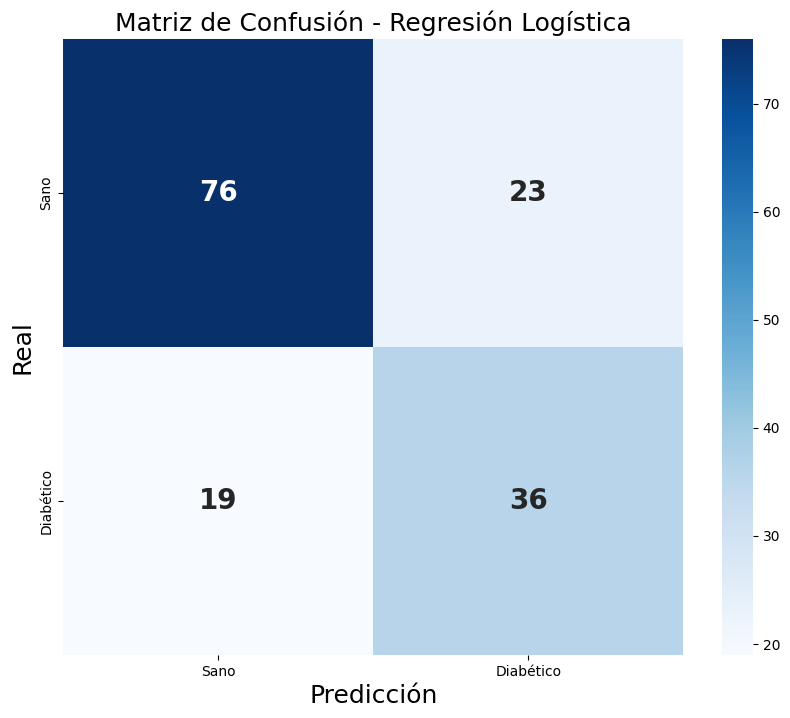

In [18]:
print("RESULTADOS REGRESIÓN LOGÍSTICA")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

plt.figure(figsize=(10, 8))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Diabético'],
            yticklabels=['Sano', 'Diabético'],
            annot_kws={"size": 20, "weight": "bold"})
plt.xlabel('Predicción', fontsize=18)
plt.ylabel('Real', fontsize=18)
plt.title('Matriz de Confusión - Regresión Logística', fontsize=18)
plt.rcParams.update({'font.size': 16})
plt.show()


### Random Forest

RESULTADOS RANDOM FOREST
Accuracy: 0.7532
              precision    recall  f1-score   support

           0       0.83      0.78      0.80        99
           1       0.64      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



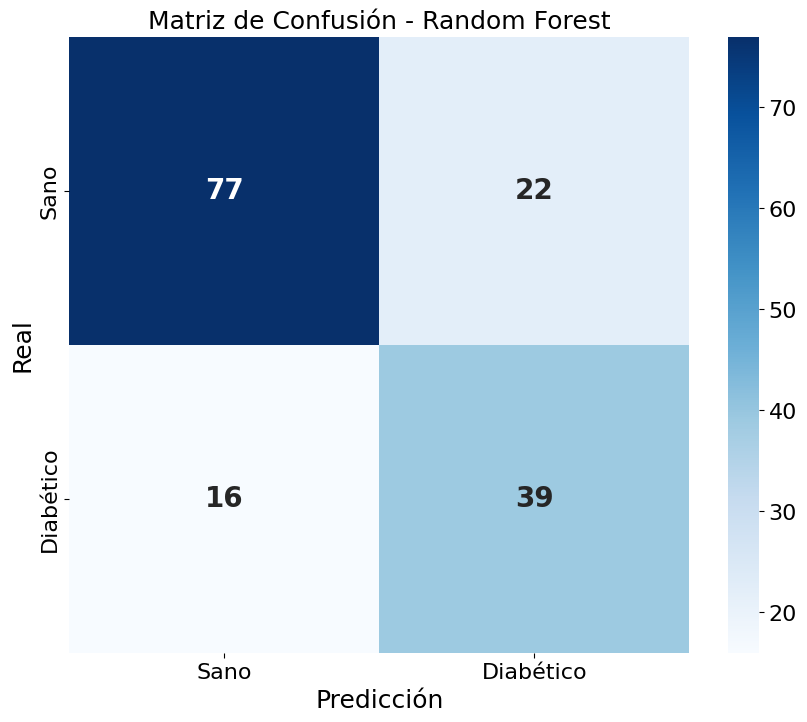

In [19]:
print("RESULTADOS RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Diabético'],
            yticklabels=['Sano', 'Diabético'],
            annot_kws={"size": 20, "weight": "bold"})
plt.xlabel('Predicción', fontsize=18)
plt.ylabel('Real', fontsize=18)
plt.title('Matriz de Confusión - Random Forest', fontsize=18)
plt.rcParams.update({'font.size': 16})
plt.show()


### Support Vector Machines (SVM)

RESULTADOS SVM
Accuracy: 0.7338
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



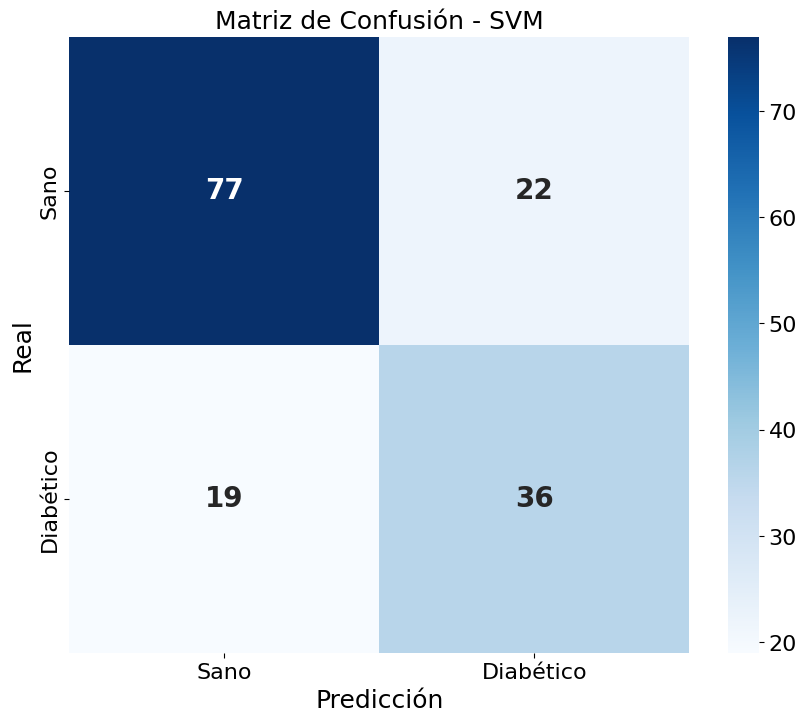

In [20]:
print("RESULTADOS SVM")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(10, 8))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Diabético'],
            yticklabels=['Sano', 'Diabético'],
            annot_kws={"size": 20, "weight": "bold"})
plt.xlabel('Predicción', fontsize=18)
plt.ylabel('Real', fontsize=18)
plt.title('Matriz de Confusión - SVM', fontsize=18)
plt.rcParams.update({'font.size': 16})
plt.show()


### Redes Neuronales

RESULTADOS RED NEURONAL
Accuracy: 0.7468
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        99
           1       0.65      0.64      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



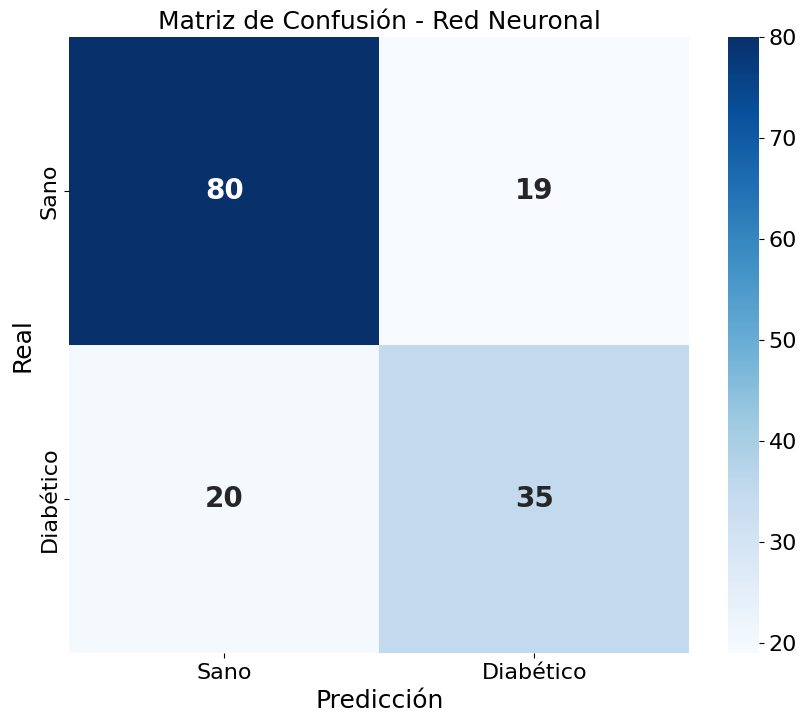

In [21]:
print("RESULTADOS RED NEURONAL")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

plt.figure(figsize=(10, 8))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Diabético'],
            yticklabels=['Sano', 'Diabético'],
            annot_kws={"size": 20, "weight": "bold"})
plt.xlabel('Predicción', fontsize=18)
plt.ylabel('Real', fontsize=18)
plt.title('Matriz de Confusión - Red Neuronal', fontsize=18)
plt.rcParams.update({'font.size': 16})
plt.show()


## Barplot Comparativo de Métricas

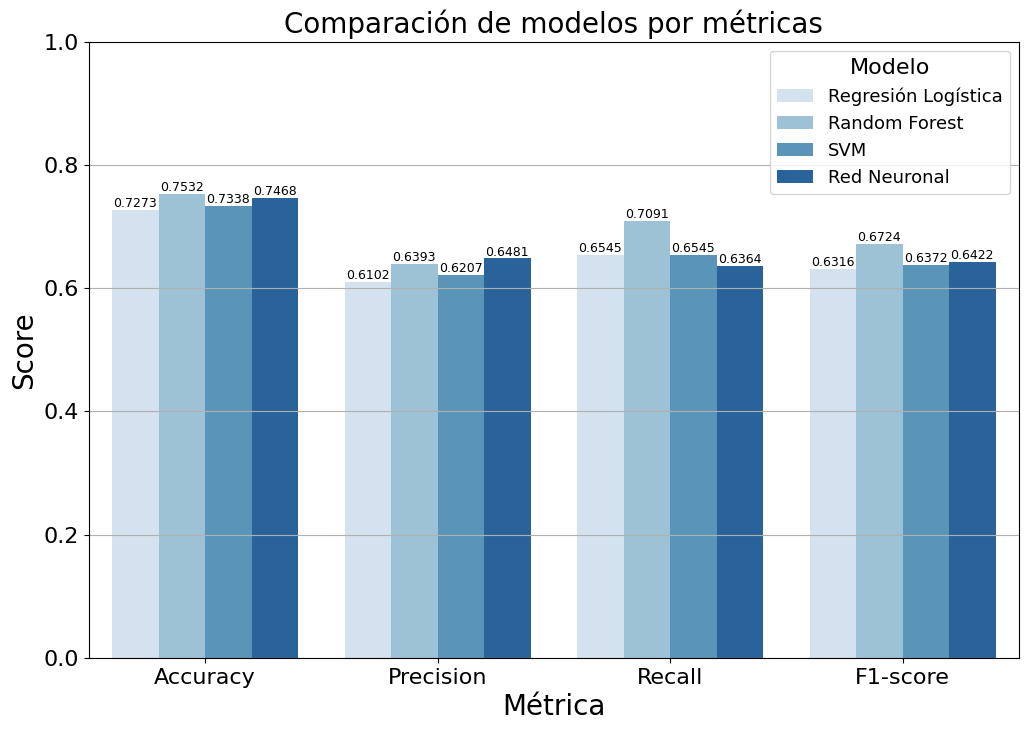

In [22]:
metrics = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Regresión Logística': [accuracy_score(y_test, y_pred_log), precision_score(y_test, y_pred_log),
                            recall_score(y_test, y_pred_log), f1_score(y_test, y_pred_log)],
    'Random Forest': [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
                      recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)],
    'SVM': [accuracy_score(y_test, y_pred_svm), precision_score(y_test, y_pred_svm),
            recall_score(y_test, y_pred_svm), f1_score(y_test, y_pred_svm)],
    'Red Neuronal': [accuracy_score(y_test, y_pred_mlp), precision_score(y_test, y_pred_mlp),
                     recall_score(y_test, y_pred_mlp), f1_score(y_test, y_pred_mlp)]
}

metrics_df = pd.DataFrame(metrics)
# melt para que seaborn pueda agrupar por modelo
metrics_melted = metrics_df.melt(id_vars='Métrica', var_name='Modelo', value_name='Score')

plt.figure(figsize=(12,8))
ax = sns.barplot(data=metrics_melted, x='Métrica', y='Score', hue='Modelo', palette='Blues')
plt.ylim(0,1)
plt.title('Comparación de modelos por métricas', fontsize=20)
plt.ylabel('Score', fontsize=20)
plt.xlabel('Métrica', fontsize=20)
plt.legend(title='Modelo', fontsize=13)
plt.grid(axis='y')

for container in ax.containers:
    labels = [f'{v:.4f}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9, fontweight='normal')

plt.rcParams.update({'font.size': 13})
plt.show()


## Curvas ROC

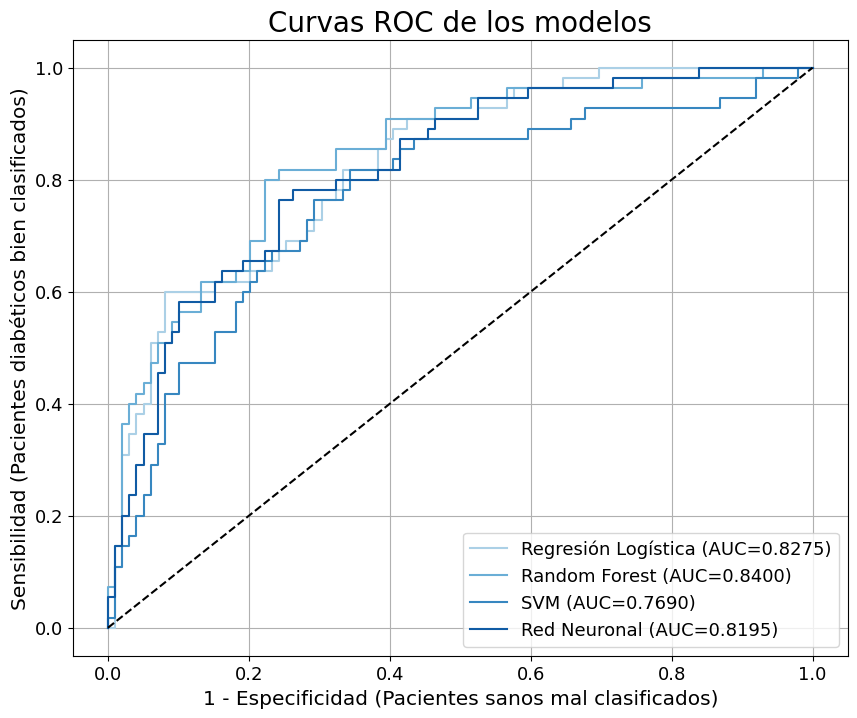

In [23]:
palette = sns.color_palette("Blues", 5)

plt.figure(figsize=(10,8))

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr, tpr, color=palette[1], label=f'Regresión Logística (AUC={auc(fpr,tpr):.4f})')

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, color=palette[2], label=f'Random Forest (AUC={auc(fpr,tpr):.4f})')

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr, tpr, color=palette[3], label=f'SVM (AUC={auc(fpr,tpr):.4f})')

y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
plt.plot(fpr, tpr, color=palette[4], label=f'Red Neuronal (AUC={auc(fpr,tpr):.4f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('1 - Especificidad (Pacientes sanos mal clasificados)', fontsize=14.5)
plt.ylabel('Sensibilidad (Pacientes diabéticos bien clasificados)', fontsize=14.5)
plt.title('Curvas ROC de los modelos', fontsize=20)
plt.rcParams.update({'font.size': 13})
plt.legend()
plt.grid()
plt.show()
